In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import builtins

_print = builtins.print

def print(*args, **kwargs):
    def colorize(arg):
        if isinstance(arg, (bool, np.bool_)):
            if arg:  # True
                return f'\033[94m{arg}\033[0m'  # Bleu
            else:    # False
                return f'\033[91m{arg}\033[0m'  # Rouge
        return arg
    
    args = [colorize(arg) for arg in args]
    _print(*args, **kwargs)

builtins.print = print

from mes_packages import *

### Explications sur le bloc sparse.py
Le fichier `sparse.py` définit la classe `COOMatrix`, qui permet de manipuler des matrices creuses (sparse) au format COO (Coordinate). Ce format est particulièrement adapté pour stocker des matrices contenant principalement des zéros, ce qui est fréquent dans les méthodes d'éléments finis.
La classe propose plusieurs fonctionnalités :
- **Initialisation** : On définit le nombre de lignes, de colonnes et d'éléments non nuls (nnz).
- **Ajout d'éléments** : La méthode `ajout` permet d'ajouter un élément non nul à la matrice, en précisant sa position et sa valeur.
- **Conversion** : Plusieurs méthodes permettent de convertir la matrice vers différents formats (`to_dense`, `to_csc`, `to_csr`) pour faciliter les calculs ou l'affichage.
- **Décomposition LU** : La méthode `lu` effectue une factorisation LU sur la matrice, utile pour la résolution de systèmes linéaires.
- **Résolution de systèmes** : Les méthodes `solveLU` et `solve` permettent de résoudre un système linéaire $Ax = b$ en utilisant la factorisation LU.
- **Affichage** : La méthode `print` affiche les caractéristiques de la matrice et son contenu.
Cette classe s'appuie sur les bibliothèques `numpy` et `scipy.sparse` pour garantir efficacité et rapidité dans les calculs sur matrices creuses. Elle est essentielle pour le traitement des systèmes issus de la discrétisation des équations aux dérivées partielles par éléments finis.

In [2]:
# Construction de deux matrices creuses identiques pour tester l'addition
Mat=COOMatrix(4,4,30)
Mat.ajout(1,0,1)
Mat.ajout(0,1,1.0)
Mat.ajout(2,2,1.0)
Mat.ajout(3,2,1.5) 
Mat.ajout(3,3,1.0)
Mat.ajout(2,3,1.0)
Mat.ajout(1,3,1.0)
Mat.ajout(3,1,5.0)
Mat.ajout(0,3,2.0)
Mat.ajout(0,3,np.pi)
Mat1dense = Mat.to_dense() 

Mat2=COOMatrix(4,4,30)
Mat2.ajout(1,0,1)
Mat2.ajout(0,1,1.0)
Mat2.ajout(2,2,1.0)
Mat2.ajout(3,2,1.5) 
Mat2.ajout(3,3,1.0)
Mat2.ajout(2,3,1.0)
Mat2.ajout(1,3,1.0)
Mat2.ajout(3,1,5.0)
Mat2.ajout(0,3,2.0)
Mat2.ajout(0,3,np.pi)
Mat2dense = Mat2.to_dense()

# Verification de l'addition en comparant la version dense
print('Verification du +')
_=Mat+Mat2 
Mat3dense = Mat.to_dense()
TEST= np.allclose(Mat3dense, Mat1dense + Mat2dense)
print('Somme correcte ?', TEST)

# Verification de la soustraction
Mat=COOMatrix(4,4,30)
Mat.ajout(1,0,1)
Mat.ajout(0,1,1.0)
Mat.ajout(2,2,1.0)
Mat.ajout(3,2,1.5) 
Mat.ajout(3,3,1.0)
Mat.ajout(2,3,1.0)
Mat.ajout(1,3,1.0)
Mat.ajout(3,1,5.0)
Mat.ajout(0,3,2.0)
Mat1dense = Mat.to_dense() 

Mat2=COOMatrix(4,4,30)
Mat2.ajout(1,0,1)
Mat2.ajout(0,1,1.0)
Mat2.ajout(2,2,1.0)
Mat2.ajout(3,2,1.5) 
Mat2.ajout(3,3,1.0)
Mat2.ajout(2,3,1.0)
Mat2.ajout(1,3,1.0)
Mat2.ajout(3,1,5.0)
Mat2.ajout(0,3,2.0)
Mat2dense = Mat2.to_dense()

print('Verification du -')
Mat = Mat-Mat2
Mat3dense = Mat.to_dense()
TEST= np.allclose(Mat3dense, Mat1dense - Mat2dense)
print('Difference correcte ?', TEST)

# Verification de la resolution via decomposition LU
Mat=COOMatrix(4,4,30)
Mat.ajout(0,0,2)
Mat.ajout(1,1,2)
Mat.ajout(2,2,2)
Mat.ajout(3,3,2)
Mat.ajout(0,1,-1)
Mat.ajout(1,0,-1)
Mat.ajout(1,2,-1)
Mat.ajout(2,1,-1)
Mat.ajout(2,3,-1)
Mat.ajout(3,2,-1)


F=np.zeros((4,1))
F[0]=2
F[1]=4
F[2]=6
F[3]=7
A=Mat.to_dense()
print(A)

Mat.lu()
X=Mat.solveLU(F)
print('TEST du LU')
F0=A@X
TEST = np.allclose(F0, F)
print('AX-F=0 par lu puis solvelu',TEST)
X0=Mat.solve(F)
F0=A@X0
TEST = np.allclose(F0, F)
print('AX-F=0 par solve',TEST)

TEST = np.allclose(X, X0)
print('X(solvelu) == X(solve) ?', TEST)


## Test de la forme sesquilineaire V* A U
print('\n=== Test de la forme sesquilineaire V^* A U ===')
V = np.array([1, 2, 3, 4])
U = np.array([1, 1, 1, 1])

# Calcul via la methode sparse puis comparaison a la version dense
result_sparse = Mat.sesquilinear_form(V, U)
result_dense = np.conj(V) @ A @ U
TEST = np.allclose(result_sparse, result_dense)
print('Test de la forme sesquilineaire')
print('Forme sesquilineaire correcte ?', TEST)


## Test de la multiplication par un scalaire
A=COOMatrix(4,4,30)
A.ajout(0,0,2)
A.ajout(1,1,2)
A.ajout(2,2,2)
A.ajout(3,3,2)
A.ajout(3,3,2)
A.ajout(0,1,-1)
A.ajout(1,0,-1)
A.ajout(1,2,-1)
A.ajout(2,1,-1)
A.ajout(2,3,-1)
A.ajout(3,2,-1)

B=100*A
Adense=A.to_dense()
Bdense=B.to_dense()
TEST = np.allclose(Bdense, 100*Adense)
print('\n=== Test de la multiplication par un scalaire ===')
print('Test de la multiplication par un scalaire :', TEST)
## Test du produit matrice-vecteur (a droite)
print('\n=== Test du produit matrice-vecteur a droite ===')
A=COOMatrix(4,4,30)
A.ajout(0,0,2)
A.ajout(1,1,2)
A.ajout(2,2,2)
A.ajout(3,3,2)
A.ajout(0,1,-1)
A.ajout(1,0,-1)
A.ajout(1,2,-1)
A.ajout(2,1,-1)
A.ajout(2,3,-1)
A.ajout(3,2,-1)
A.ajout(3,3,1j)

F=np.zeros((4,1))
F[0]=1
F[1]=2
F[2]=3
F[3]=4
A_dense=A.to_dense()
print(A_dense)
F_result_dense=A_dense@F
F_result_sparse=A@F
TEST = np.allclose(F_result_sparse, F_result_dense)
print('Test du produit matrice-vecteur :', TEST)

print('\n=== Test du produit matrice-vecteur a gauche ===')

F_result_dense=F.T@A_dense
F_result_sparse=A.produit_gauche(F.T)
TEST = np.allclose(F_result_sparse, F_result_dense)
print('Test du produit vecteur-matrice :', TEST)

Verification du +
Somme correcte ? True
Verification du -
Difference correcte ? True
[[ 2.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  2.+0.j]]
TEST du LU
AX-F=0 par lu puis solvelu True
AX-F=0 par solve True
X(solvelu) == X(solve) ? True

=== Test de la forme sesquilineaire V^* A U ===
Test de la forme sesquilineaire
Forme sesquilineaire correcte ? True

=== Test de la multiplication par un scalaire ===
Test de la multiplication par un scalaire : True

=== Test du produit matrice-vecteur a droite ===
[[ 2.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [-1.+0.j  2.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  2.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  2.+1.j]]
Test du produit matrice-vecteur : True

=== Test du produit matrice-vecteur a gauche ===
Test du produit vecteur-matrice : True


# Exemple d'utilisation du spy
La methode `Mat.spy()` affiche la structure de la matrice creuse sous forme de points : chaque point correspond a un coefficient non nul.
Cela permet de visualiser rapidement les positions des coefficients non nuls en affichant leurs valeurs à l'aide d'une couleur.
C'est utile pour verifier la structure attendue et detecter des erreurs d'assemblage.

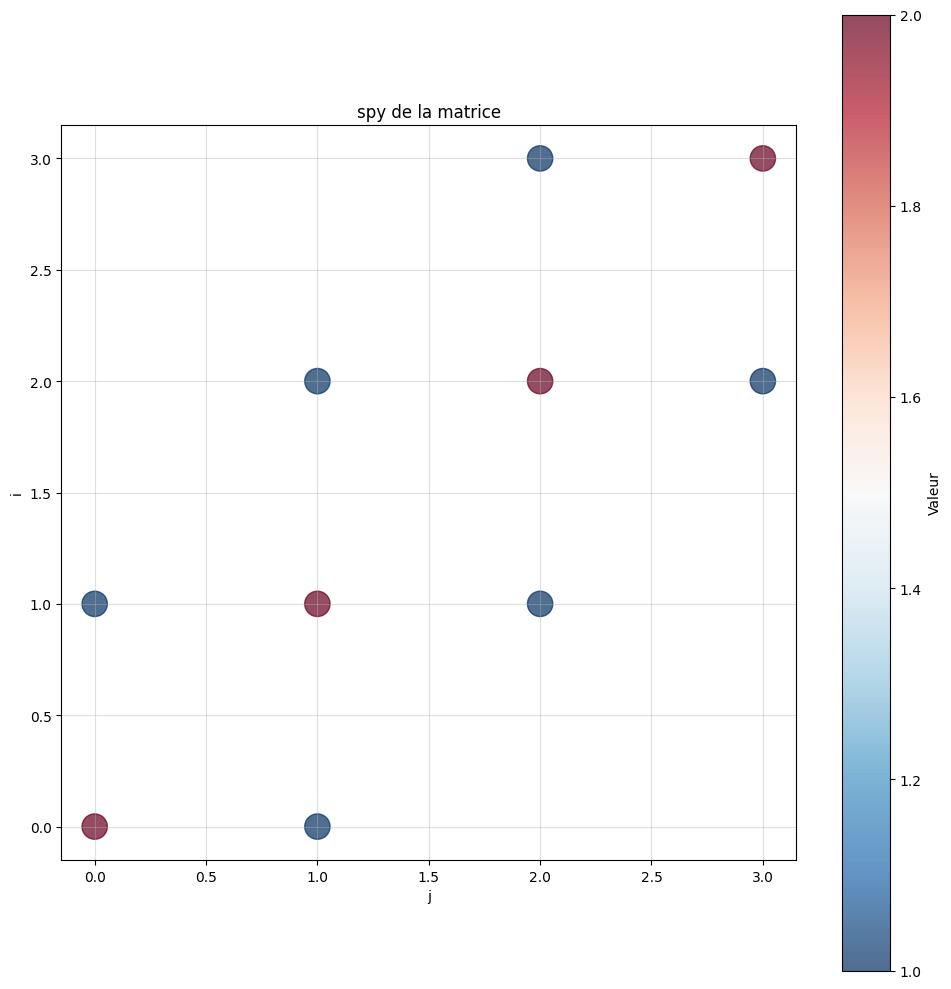

In [3]:
_=Mat.spy()